## What is Regression in Machine Learning?
Regression is a supervised machine learning technique used when the target variable (the output we want to predict) is continuous (numeric) rather than categorical.

It is about finding the relationship (mathematical function) between:

- `Independent Variables` (features, predictors, inputs, X): e.g., size of house, number of bedrooms, years of experience.
- `Dependent Variable` (target, output, Y): e.g., price of house, employee salary.

### Examples of Regression Problems

#### 1. House Price Prediction

- Input: Size (sq. ft), number of rooms, location.
- Output: House price in dollars.

#### 2. Stock Market Prediction

- Input: Previous stock prices, trading volume.
- Output: Next-day stock price.

#### 3. Medical Use Case

- Input: Age, BMI, blood pressure.
- Output: Patient’s blood sugar level.

#### 4. Weather Forecasting

- Input: Humidity, wind speed, past temperature.
- Output: Tomorrow’s temperature.

### Types of Regression Models
#### 1. Simple Linear Regression

Assumes a linear relationship between input and output.

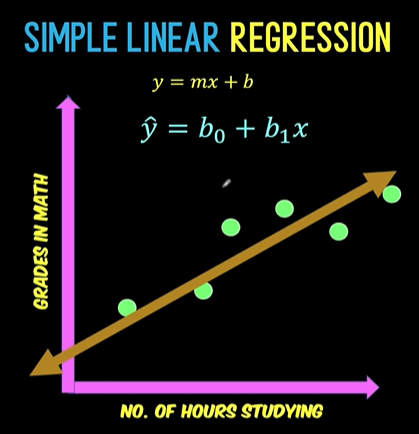 | 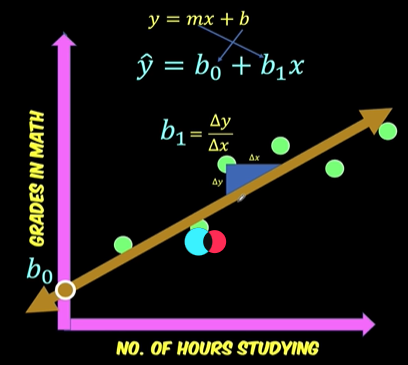

<table>
<tr>
<td>

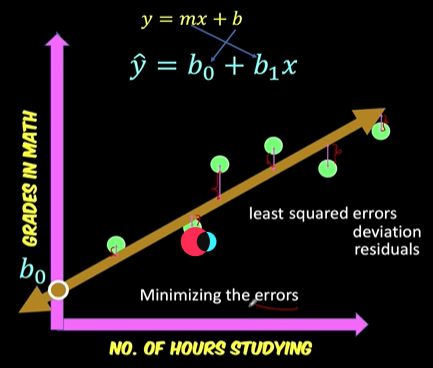

</td>
<td>

### Why “Squared”?
- If we just summed raw errors, **positive and negative would cancel out**.  
- **Squaring ensures all errors are positive.**  
- Also, squaring **penalizes larger errors more strongly**.  

</td>
</tr>
</table>


Least Squared Error is the method linear regression uses to find the best-fitting line by minimizing the sum of squared differences between actual and predicted values.

Equation: 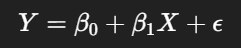

Where:

- Y = predicted output
- 𝛽0 = intercept (where the line crosses the y-axis)
- 𝛽1 = slope of the line/weight of the feature
- ϵ = error term



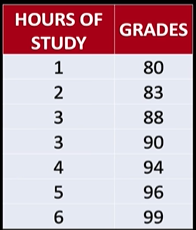 | 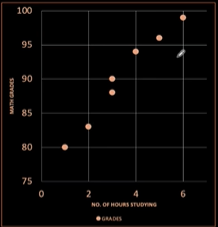 | 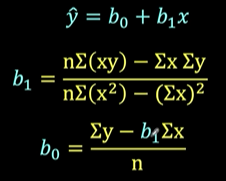

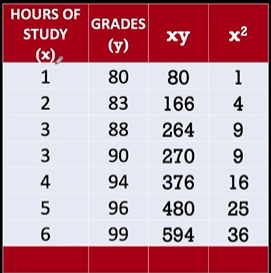 

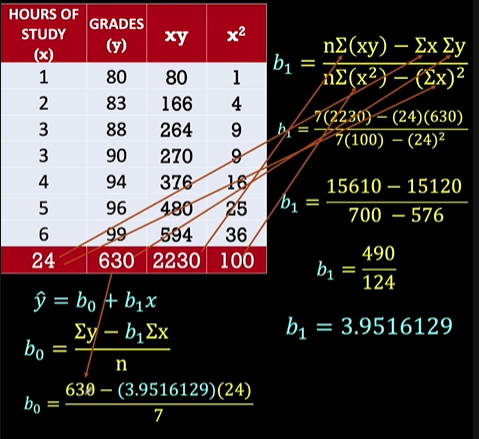 | 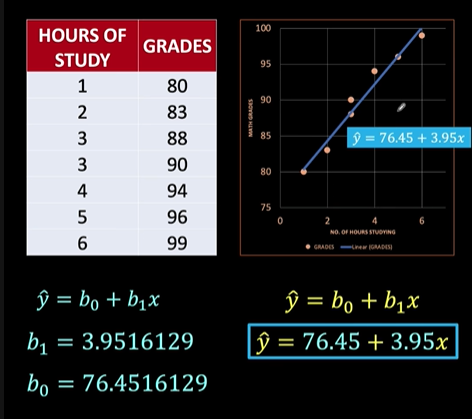

### How Linear regression works

| 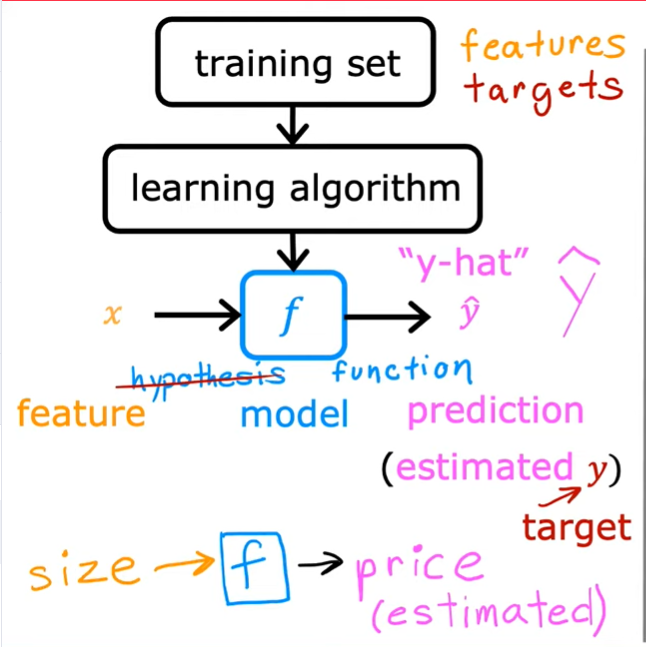 | 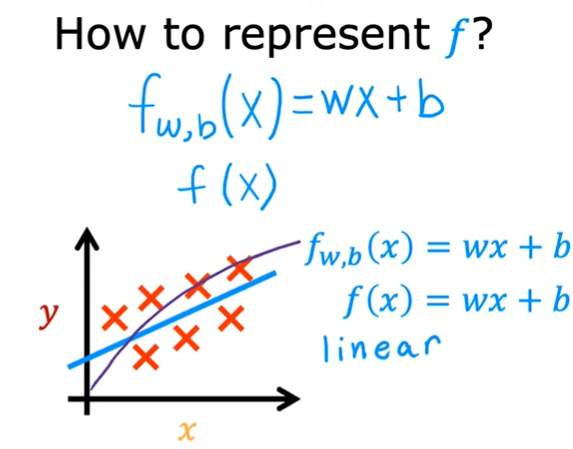 | 
|-----------------------------------|----------------------------------------|

### Cost Function

A `cost function` (also called a loss function) measures how well a machine learning model is performing.

- It calculates the difference between the actual values (from the dataset) and the predicted values (from the model).
- The goal of training is to minimize this cost so the predictions get as close as possible to reality.

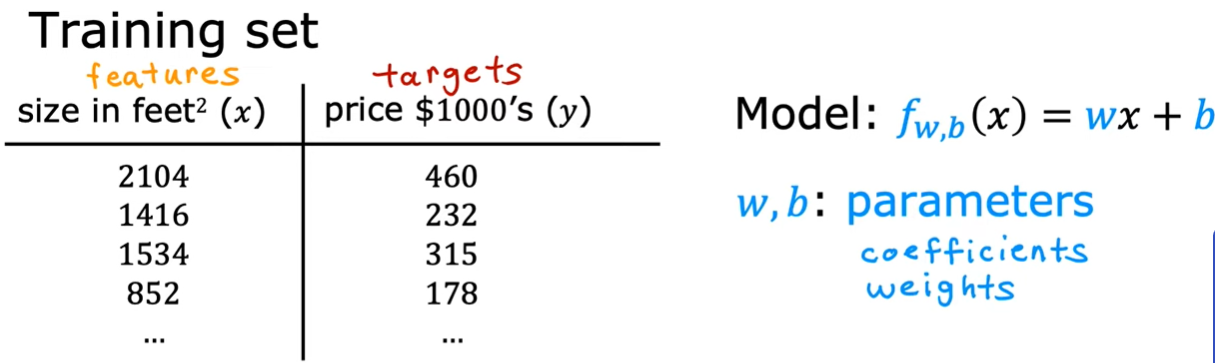




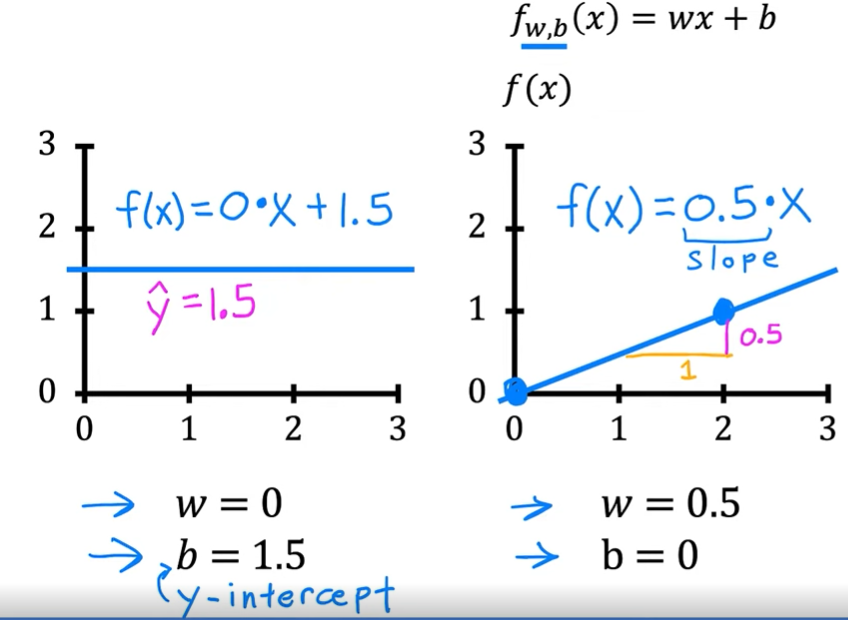

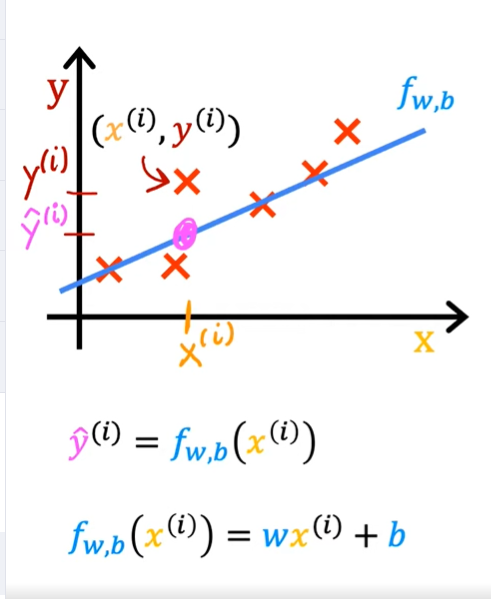

#### import libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the dataset
df = pd.read_csv("Salary_dataset.csv")

# Display first rows
print(df.head())


   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0


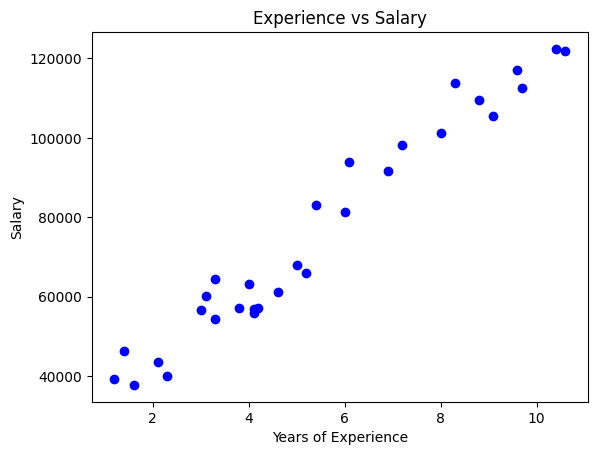

In [3]:
# visualize the data
plt.scatter(df['YearsExperience'], df['Salary'], color='blue')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

In [4]:
# spli the data into features and target
X = df[['YearsExperience']]  # Independent variable
y = df['Salary']             # Dependent variable

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept (β0):", model.intercept_)
print("Slope (β1):", model.coef_[0])


Intercept (β0): 24380.20147947369
Slope (β1): 9423.81532303098


In [6]:
# make predictions
y_pred = model.predict(X_test)

# Compare actual vs predicted
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison.head())


      Actual      Predicted
27  112636.0  115791.210113
15   67939.0   71499.278095
23  113813.0  102597.868661
17   83089.0   75268.804224
8    64446.0   55478.792045


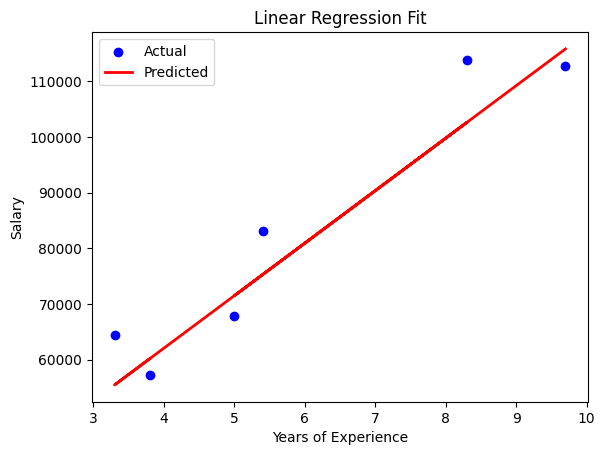

In [7]:
plt.scatter(X_test, y_test, color='blue', label="Actual")
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Predicted")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()


## Multiple Linear Regression (MLR)

Multiple Linear Regression is a supervised learning algorithm used to predict a **continuous variable** using **two or more predictors (independent variables)**.  

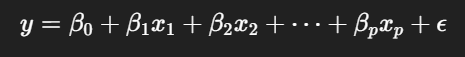

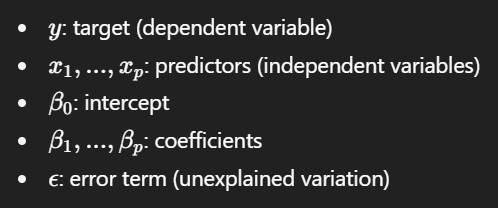

---

### 2. Coefficients in Multiple Linear Regression
Coefficients (β) are the `weights` the model learns. They tell us:

- **Direction (positive/negative effect):**  
  - Positive → an increase in the feature increases \(y\).  
  - Negative → an increase in the feature decreases \(y\).  

- **Magnitude:**  
  - Large coefficient → strong effect.  
  - Small coefficient → weak effect.  

**Example (House Price Prediction):**  

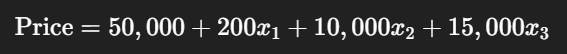

- \(200\): Each additional sq. ft. increases price by \$200 (holding bedrooms & location constant).  
- \(10,000\): Each extra bedroom adds \$10,000.  
- \(15,000\): A better location score adds \$15,000.  

**Key detail:** In multiple regression, coefficients show the effect of **one variable while keeping others constant**.  

### 3. Variance & Variability in MLR
In regression, variability tells us **how much the data is spread out and how well the model explains it**.  

We split variance into parts:  

#### (a) Total Variability (SST)  - Total sum of squares
How much \(y\) varies around its mean:  

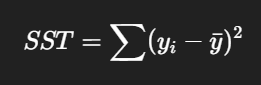

#### (b) Explained Variability (SSR)  - Regression sum of squares
How much of that variability is explained by the regression model:  

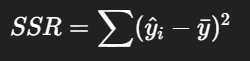

#### (c) Unexplained Variability (SSE)  - Sum of Squared Errors
The error left after regression (residuals):  

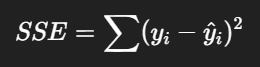 

Relationship:  

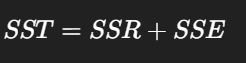


### 4. Connection to \(R^2\)
The proportion of variability explained by the model:  

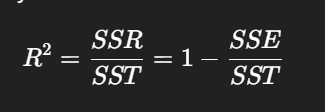

- (R^2 = 0.8\) → Model explains 80% of the variance in \(y\).  
- **Adjusted \(R^2\)** corrects for number of predictors (penalizes unnecessary features).  

### 5. Variance of the Coefficients
Each coefficient has its own **variance (uncertainty):**  

- A **large variance** → coefficient is unstable (sensitive to new data).  
- A **small variance** → coefficient is reliable.  

We use this to compute **standard errors**, **confidence intervals**, and **p-values** to test if coefficients are statistically significant.  

### 6. Assumptions
For coefficients and variance to be valid, we assume:  
1. **Linearity** – relationship between predictors & outcome is linear.  
2. **Independence** – observations are independent.  
3. **Homoscedasticity** – errors have constant variance.  
4. **Normality** – errors are normally distributed.  
5. **No Multicollinearity** – predictors are not too correlated.  

### Summary
- **Coefficients** show how much each predictor affects the target (while holding others constant).  
- **Variance** measures both (1) the variability in \(y\) (explained vs unexplained) and (2) the uncertainty in the coefficients themselves.  
- Together, they tell us **how well the model fits** and **how reliable the feature effects are**.  


### Problem Definition

We are trying to predict house prices in Kenya based on features like number of bedrooms, bathrooms, and size of the house.

We want to know:

What makes a house more expensive?
Can we learn a pattern from past houses?

- Type: Supervised Learning
- Task: Regression
- Target: Price (continuous variable)
- Goal: Learn pricing patterns from historical property data

### Import Libraries

In [2]:
# Data Handling and Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Preprocessing tools
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


### Load Data

In [51]:
df = pd.read_csv("nairobi_house_prices.csv")
df.head()

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN


## Exploratory Data Analysis (EDA)

### Structure inspection

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    str    
 1   propertyType  204 non-null    str    
 2   Location      204 non-null    str    
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    99 non-null     str    
 6   Land size     64 non-null     str    
dtypes: float64(2), str(5)
memory usage: 18.8 KB


#### Extract Digits Only for Price

In [53]:
df['Price'].unique()

<ArrowStringArray>
['KSh 350 000 000',  'KSh 30 000 000', 'KSh 325 000 000',  'KSh 80 000 000',
  'KSh 25 500 000', 'KSh 300 000 000', 'KSh 160 000 000',   'KSh 9 500 000',
 'KSh 150 000 000',  'KSh 42 000 000', 'KSh 115 300 000', 'KSh 115 000 000',
  'KSh 35 000 000', 'KSh 220 000 000',   'KSh 9 000 000',   'KSh 7 200 000',
 'KSh 200 000 000',  'KSh 68 000 000',  'KSh 28 390 000',  'KSh 17 500 000',
  'KSh 18 000 000',  'KSh 38 000 000',  'KSh 78 000 000',  'KSh 75 000 000',
  'KSh 32 000 000', 'KSh 140 000 000',  'KSh 50 000 000',  'KSh 70 000 000',
  'KSh 12 000 000', 'KSh 322 550 000', 'KSh 380 000 000',   'KSh 8 700 000',
 'KSh 240 000 000',   'KSh 8 000 000',  'KSh 12 600 000',   'KSh 7 000 000',
  'KSh 18 330 000',  'KSh 20 500 000',  'KSh 16 285 499',  'KSh 12 500 000',
  'KSh 23 500 000',  'KSh 33 500 000',  'KSh 16 000 000',  'KSh 21 500 000',
  'KSh 22 500 000',  'KSh 45 000 000',  'KSh 24 000 000',  'KSh 62 500 000',
  'KSh 34 000 000',   'KSh 5 700 000',   'KSh 6 500 000',

In [54]:
# Extract numbers only
df["Price"] = df["Price"].str.extract(r"(\d+)").astype(float)

In [55]:
df['Price'].unique()

array([350.,  30., 325.,  80.,  25., 300., 160.,   9., 150.,  42., 115.,
        35., 220.,   7., 200.,  68.,  28.,  17.,  18.,  38.,  78.,  75.,
        32., 140.,  50.,  70.,  12., 322., 380.,   8., 240.,  20.,  16.,
        23.,  33.,  21.,  22.,  45.,  24.,  62.,  34.,   5.,   6.,  13.,
       948., 142., 100.,  90.,  39.,  72.,  27.,  40.,  79., 110.,  29.,
        26.,  10.,  99.,  15.,  88., 143.,  95., 180., 250.,  47.,  14.,
         3.,  11.,  60., 120.])

In [56]:
df["House size"].unique()

<ArrowStringArray>
[       nan,   '230 m²',   '105 m²',   '280 m²',   '586 m²',    '90 m²',
    '70 m²',  '399 m²"',   '203 m²',   '300 m²',   '423 m²',   '283 m²',
   '385 m²',   '150 m²',    '50 m²',    '57 m²',    '65 m²',  '1 acres',
   '399 m²',   '141 m²',   '260 m²',   '186 m²',    '96 m²',   '159 m²',
    '86 m²',   '302 m²',   '160 m²',   '139 m²',   '202 m²',   '125 m²',
   '223 m²',   '445 m²',   '338 m²',    '48 m²',   '101 m²',   '800 m²',
    '61 m²',        '1',   '168 m²',   '400 m²',   '130 m²',   '116 m²',
   '190 m²',   '600 m²',   '200 m²',    '54 m²',   '110 m²',   '165 m²',
    '60 m²',    '64 m²',    '85 m²',    '75 m²', '2 025 m²',    '95 m²',
   '234 m²']
Length: 55, dtype: str

In [57]:
df["House size"] = df["House size"].astype(str).str.extract(r"(\d+)").astype(float)

In [58]:
df["Land size"] = df["Land size"].astype(str).str.extract(r"(\d+)").astype(float)

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         204 non-null    float64
 1   propertyType  204 non-null    str    
 2   Location      204 non-null    str    
 3   Bedroom       183 non-null    float64
 4   bathroom      181 non-null    float64
 5   House size    99 non-null     float64
 6   Land size     64 non-null     float64
dtypes: float64(5), str(2)
memory usage: 14.7 KB


### Distribution of features

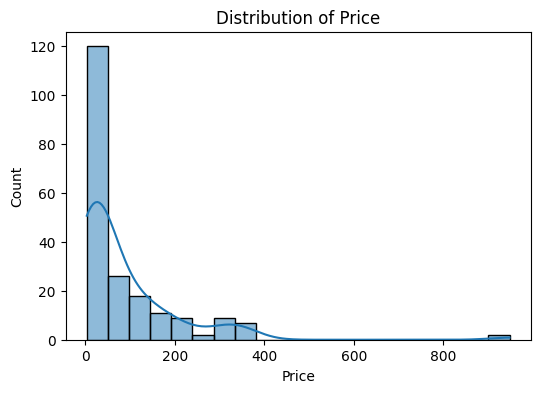

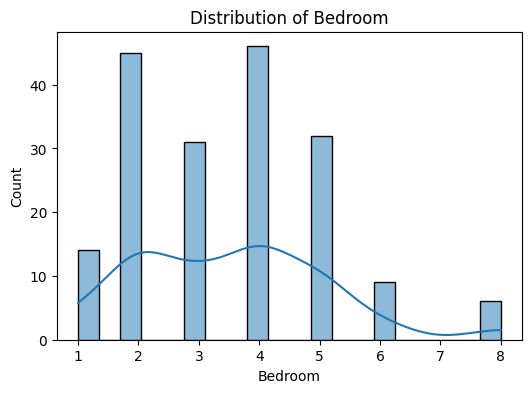

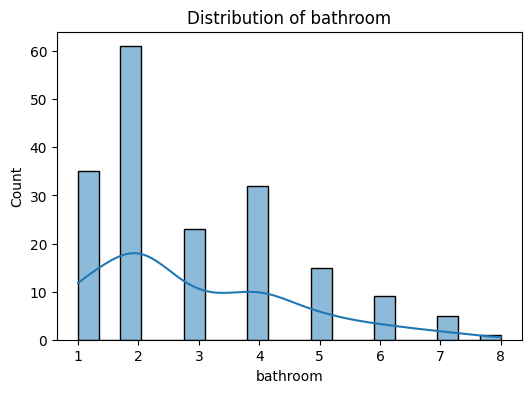

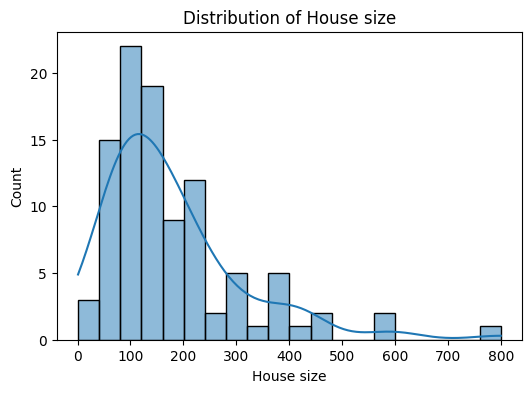

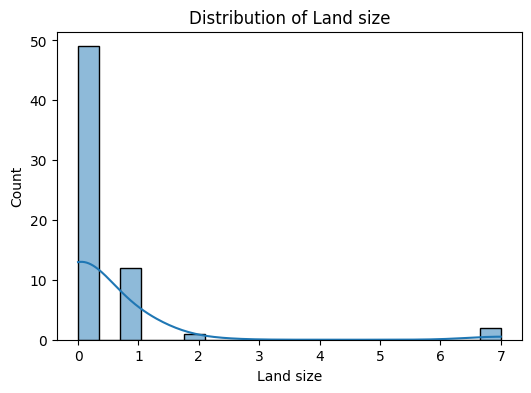

In [60]:
num_cols = ['Price', 'Bedroom', 'bathroom', 'House size', 'Land size']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

### Outlier Detection

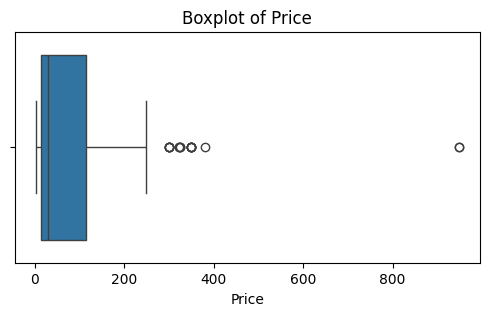

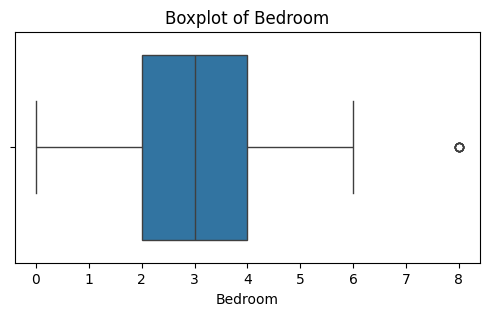

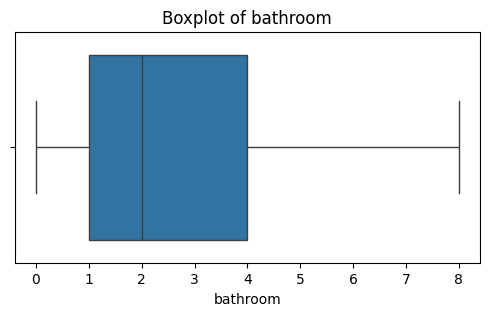

In [89]:
num_cols = ['Price', 'Bedroom', 'bathroom']

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Investigating the outliers

In [90]:
num_cols = ['Price', 'Bedroom', 'bathroom']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n{col}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)}")


Price
Lower bound: -135.62
Upper bound: 263.38
Number of outliers: 18

Bedroom
Lower bound: -1.00
Upper bound: 7.00
Number of outliers: 6

bathroom
Lower bound: -3.50
Upper bound: 8.50
Number of outliers: 0


### Price outliers

In [92]:
price_outliers = df[df['Price'] > 266.5]

price_outliers[['Price', 'Bedroom', 'bathroom',
                'propertyType']].sort_values(
                    'Price', ascending=False
)

,Price,Bedroom,bathroom,propertyType
77,948.0,0.0,0.0,Vacant Land
76,948.0,0.0,0.0,Vacant Land
37,380.0,0.0,0.0,Vacant Land
0,350.0,4.0,4.0,Townhouse
125,350.0,5.0,5.0,Townhouse
86,350.0,4.0,4.0,Townhouse
96,350.0,0.0,0.0,Vacant Land
141,350.0,4.0,4.0,Townhouse
95,350.0,4.0,4.0,Townhouse
2,325.0,0.0,0.0,Vacant Land


- The highest prices are 948M, 948M, and 380M, all for Vacant Land.
- Several Townhouses are priced at 300M–350M and have 4–6 bedrooms and 3–6 bathrooms.
- There are no obviously impossible values such as negative prices or a 5-bedroom property priced at 0.

Price has 18 observations above the IQR upper bound of 263.38. However, further investigation shows that these observations correspond to high-value vacant land and townhouses, rather than obvious data-entry errors. Therefore, the observations will be retained because they represent legitimate variations in property prices.

In [94]:
df[df['Bedroom'] > 7][
    ['Price', 'propertyType', 'Location', 'Bedroom', 'bathroom']
]

,Price,propertyType,Location,Bedroom,bathroom
18,200.0,Townhouse,Runda,8.0,8.0
26,200.0,Townhouse,Runda,8.0,7.0
46,200.0,Townhouse,Runda,8.0,7.0
80,200.0,Townhouse,Runda,8.0,7.0
107,200.0,Townhouse,Runda,8.0,7.0
200,200.0,Townhouse,Runda,8.0,7.0


Bedroom has 6 potential outliers with values of 8 bedrooms. After investigation, all six properties are townhouses located in Runda, with 7–8 bathrooms and a price of 200M. These values appear to represent legitimate large properties rather than data-entry errors. Therefore, the outliers will be retained.

There are no bathroom outliers according to the IQR method.

## Missing values Analysis

In [62]:
df.isnull().sum()

Price             0
propertyType      0
Location          0
Bedroom          21
bathroom         23
House size      105
Land size       140
dtype: int64

In [68]:
df.isnull().sum() / len(df) * 100

Price            0.000000
propertyType     0.000000
Location         0.000000
Bedroom         10.294118
bathroom        11.274510
House size      51.470588
Land size       68.627451
dtype: float64

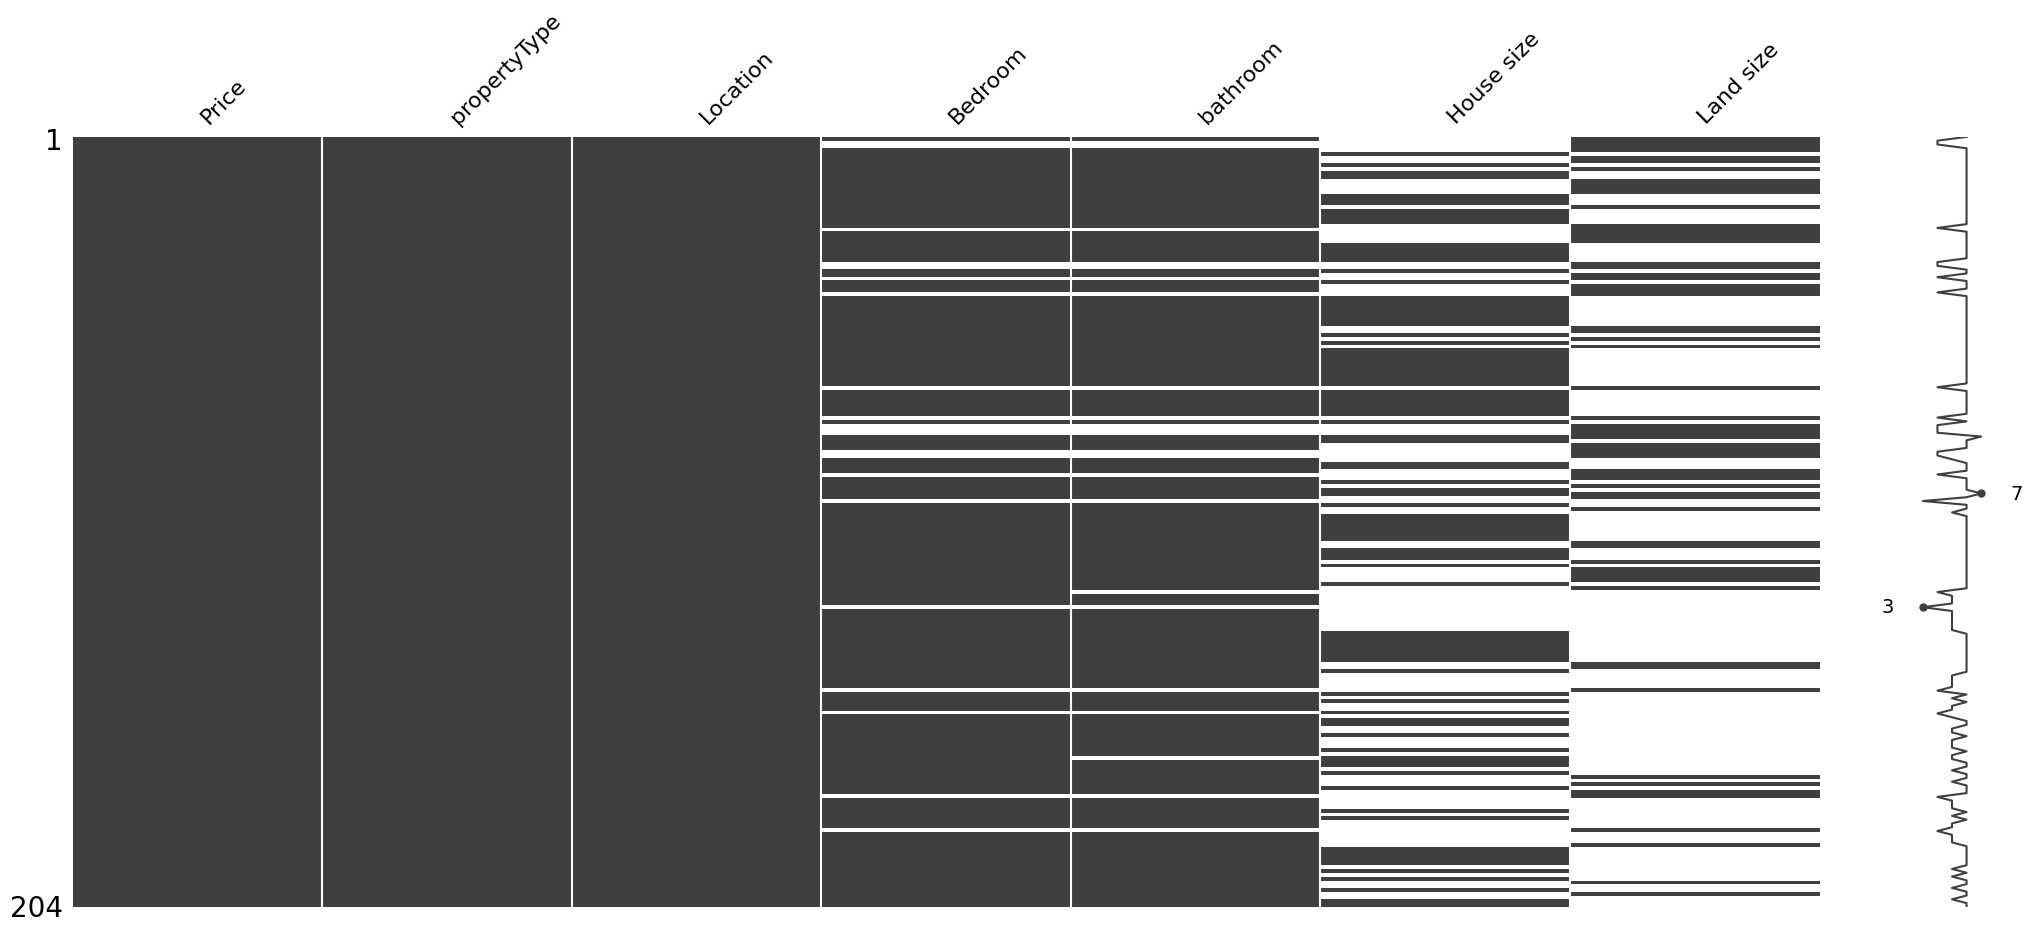

In [64]:
msno.matrix(df)
plt.show()

In [65]:
# Convert missingness into binary flags
df_miss = df.copy()

df_miss['Bedroom_missing'] = df_miss['Bedroom'].isnull().astype(int)
df_miss['Bathroom_missing'] = df_miss['bathroom'].isnull().astype(int)
df_miss['House_size_missing'] = df_miss['House size'].isnull().astype(int)
df_miss['Land_size_missing'] = df_miss['Land size'].isnull().astype(int)

We convert missing values into a classification problem: missing vs not missing.

### Group by property type

Now we check average missingness per category

In [67]:
missing_by_type = df_miss.groupby('propertyType')[
    ['Bedroom_missing', 'Bathroom_missing', 
     'House_size_missing', 'Land_size_missing']
].mean() * 100

missing_by_type

,Bedroom_missing,Bathroom_missing,House_size_missing,Land_size_missing
propertyType,,,,
Apartment,0.0,1.923077,26.923077,91.346154
Commercial Property,100.0,100.000000,100.000000,0.000000
Industrial Property,100.0,100.000000,100.000000,0.000000
Townhouse,0.0,0.000000,71.794872,53.846154
Townhuse,0.0,0.000000,100.000000,0.000000
Vacant Land,100.0,100.000000,94.736842,15.789474


### Key Insight: Missingness is structured (NOT random)

#### A. Apartment

- **Bedroom_missing** = 0.0 → fully reliable  
- **Bathroom_missing** = 0.02 → almost complete  
- **House_size_missing** = 0.27 → partially missing  
- **Land_size_missing** = 0.91 → mostly irrelevant  

> Apartments are **floor-plan driven**, not land-driven.

- Land size is basically **noise** for this class.
- This could indicate that land size is simply not usually provided for apartments, because buyers are primarily interested in the apartment/unit rather than the individual land parcel.

So the missingness appears to be structural.

#### B. Commercial Property

- Bedroom = 100% missing  
- Bathroom = 100% missing  
- House size = 100% missing  
- Land size = 0% missing  

> Only **land size matters**.

- Everything else is structurally meaningless.

#### C. Industrial Property

Same pattern as commercial.

- Only **land size is valid**
- Everything else should NOT be imputed as `real values`

#### D. Townhouse

- Bedroom_missing = 0  
- Bathroom_missing = 0  
- House_size_missing = 0.72 (high!)  
- Land_size_missing = 0.54  

> Rooms exist and are reliable  
- Size variables are inconsistently recorded  

> This is a **partially structured residential type**

#### E. Townhouse (typo)

- House_size_missing = 100%  
- Land_size_missing = 0%  

### Important insight:
This is NOT just a typo issue anymore.

It behaves like a **different data subgroup**.

> We must fix the label first or risk model distortion.

#### F. Vacant Land

- Bedroom = 100% missing  
- Bathroom = 100% missing  
- House size = 94% missing  
- Land size = 16% missing  

> Land is the **primary feature**
- Everything else is irrelevant

### What this means for Linear Regression

Linear regression assumes:

> Numeric relationships are meaningful and consistent

So we must ensure:

#### Avoid:
- Fake values in irrelevant fields  
- Global mean imputation  
- Treating all property types equally  

#### Use:
- Group-aware imputation  
- “Not applicable” encoding  
- Missing indicators  

This table shows that missing data is structured, not random.

For example, vacant land has no bedrooms by definition, while apartments rarely have land size.

This helps us decide how to clean and engineer features before building our model.

### Fixing the dataset 

We do NOT use one global imputation method.

##### Fix data quality issue first

In [69]:
# correct categories first:
df['propertyType'] = df['propertyType'].replace({'Townhuse': 'Townhouse'})

#### Inspect categories first

Always start by seeing what’s actually inside:

In [70]:
df['propertyType'].value_counts()

propertyType
Apartment              104
Townhouse               79
Vacant Land             19
Commercial Property      1
Industrial Property      1
Name: count, dtype: int64

### an important issue with Vacant Land, These aren't really missing values. They are not applicable.

In [76]:
df.loc[df['propertyType'] == 'Vacant Land', 'Bedroom'] = \
    df.loc[df['propertyType'] == 'Vacant Land', 'Bedroom'].fillna(0)

df.loc[df['propertyType'] == 'Vacant Land', 'bathroom'] = \
    df.loc[df['propertyType'] == 'Vacant Land', 'bathroom'].fillna(0)

We will not replace vacant-land bedrooms/bathrooms with a median such as 2 or 3 bedrooms. That would introduce false information into the dataset.

### Fill Bedroom and bathroom using the median by property type

In [79]:
# Fill remaining Bedroom missing values
df['Bedroom'] = df.groupby('propertyType')['Bedroom'].transform(
    lambda x: x.fillna(x.median())
)

# Fill remaining bathroom missing values
df['bathroom'] = df.groupby('propertyType')['bathroom'].transform(
    lambda x: x.fillna(x.median())
)

In [80]:
df[['Bedroom', 'bathroom']].isnull().sum()

Bedroom     2
bathroom    2
dtype: int64

In [81]:
df = df.drop(columns=['House size'])

In [82]:
df = df.drop(columns=['Land size'])

In [83]:
df.isnull().sum()

Price           0
propertyType    0
Location        0
Bedroom         2
bathroom        2
dtype: int64

In [84]:
df[df['Bedroom'].isnull() | df['bathroom'].isnull()]

,Price,propertyType,Location,Bedroom,bathroom
146,143.0,Commercial Property,Kilimani,NaN,NaN
183,20.0,Industrial Property,Mombasa Rd,NaN,NaN


In [85]:
df = df[~df['propertyType'].isin([
    'Commercial Property',
    'Industrial Property'
])]

In [99]:
df['propertyType'].value_counts()

KeyError: 'propertyType'

In [87]:
df.isnull().sum()

Price           0
propertyType    0
Location        0
Bedroom         0
bathroom        0
dtype: int64

### Encoding

#### propertyType - One-Hot Encoding

In [95]:
df = pd.get_dummies(df, columns=["propertyType"], drop_first=True)

In [96]:
df.info()   

<class 'pandas.DataFrame'>
Index: 202 entries, 0 to 203
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     202 non-null    float64
 1   Location                  202 non-null    str    
 2   Bedroom                   202 non-null    float64
 3   bathroom                  202 non-null    float64
 4   propertyType_Townhouse    202 non-null    bool   
 5   propertyType_Vacant Land  202 non-null    bool   
dtypes: bool(2), float64(3), str(1)
memory usage: 9.9 KB


In [97]:
bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df

In [98]:
df.head()

,Price,Location,Bedroom,bathroom,propertyType_Townhouse,propertyType_Vacant Land
0,350.0,Runda,4.0,4.0,1,0
1,30.0,Karen,0.0,0.0,0,1
2,325.0,Westlands,0.0,0.0,0,1
3,80.0,Kitisuru,5.0,5.0,1,0
4,25.0,Kileleshwa,4.0,4.0,0,0


#### Location - Frequency Encoding

In [100]:
# Create frequency map
location_freq = df["Location"].value_counts(normalize=True)

In [101]:
# Map into dataset
df["Location_encoded"] = df["Location"].map(location_freq)

In [102]:
# Drop original column
df = df.drop("Location", axis=1)

##### Why this is powerful (important insight)

Location importance = frequency in market data

> This captures:

- demand areas (high frequency)
- rare luxury areas (low frequency)

##### Why NOT one-hot for Location?

Because:

- 25+ columns → high dimensionality
- many locations have 1 sample - noise
- Ridge/Lasso would struggle with sparse data

In [103]:
df.info()

<class 'pandas.DataFrame'>
Index: 202 entries, 0 to 203
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Price                     202 non-null    float64
 1   Bedroom                   202 non-null    float64
 2   bathroom                  202 non-null    float64
 3   propertyType_Townhouse    202 non-null    int64  
 4   propertyType_Vacant Land  202 non-null    int64  
 5   Location_encoded          202 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 11.0 KB


In [104]:
df.isnull().sum()

Price                       0
Bedroom                     0
bathroom                    0
propertyType_Townhouse      0
propertyType_Vacant Land    0
Location_encoded            0
dtype: int64

In [106]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix['Price'].sort_values(ascending=False)

Price                       1.000000
propertyType_Vacant Land    0.369572
propertyType_Townhouse      0.354395
bathroom                    0.230549
Bedroom                     0.150284
Location_encoded           -0.291796
Name: Price, dtype: float64

1. Vacant Land — 0.370

There is a moderate positive association between being classified as vacant land and price. In the dataset, vacant-land properties tend to be associated with higher prices.

2. Townhouse — 0.354

There is also a moderate positive association between being a townhouse and price. Townhouses tend to have higher prices relative to the reference property type used when creating the dummy variables.

3. Bathroom — 0.231

There is a weak positive relationship. As the number of bathrooms increases, price tends to increase somewhat, but the relationship isn't particularly strong.

4. Bedroom — 0.150

This is a very weak positive relationship. Surprisingly, the number of bedrooms alone doesn't explain much of the variation in property prices in this dataset.

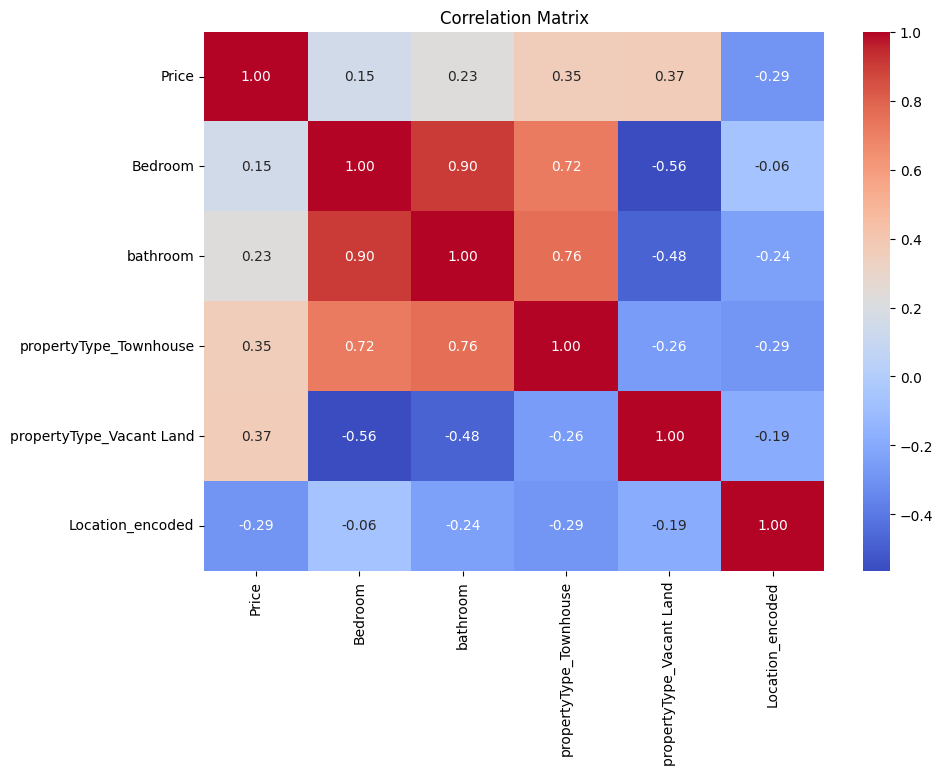

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

#### Define Features and Target

In [108]:
X = df.drop("Price", axis=1)
y = df["Price"]

#### Train-Test Split

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Scaling (VERY IMPORTANT)

We scale because:

- Linear models are sensitive to feature magnitude
- Polynomial features explode in scale
- Ridge/Lasso depend heavily on scale

In [110]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Baseline: Linear Regression Pipeline

In [111]:
lin_model = LinearRegression()

# Train the model
lin_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [112]:
# Make predictions
y_pred_lin = lin_model.predict(X_test_scaled)

In [113]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred_lin)
mse = mean_squared_error(y_test, y_pred_lin)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lin)

print("Linear MAE:", mae)
print("Linear MSE:", mse)
print("Linear RMSE:", rmse)
print("Linear R2:", r2)

Linear MAE: 59.967897653079426
Linear MSE: 18760.843911337215
Linear RMSE: 136.97023001855993
Linear R2: 0.3094630489685367


### Linear Regression Model – Key Insights
- The model has an MAE of KSh 59.97 million, meaning predictions are off by approximately KSh 60 million on average.
- The RMSE is KSh 136.97 million, considerably higher than the MAE, suggesting the model makes some very large prediction errors.
- The MSE is 18,760.84, further indicating the presence of substantial errors.
- The R² of 0.309 means the model explains approximately 30.9% of the variation in property prices, while about 69.1% remains unexplained by the variables included.
- Overall, Linear Regression provides a relatively weak baseline for predicting property prices, suggesting that other property characteristics or more flexible modelling approaches may be needed to improve prediction performance.

In [114]:
# Compute Residuals
residuals = y_test - y_pred_lin

##### Residual vs Predicted Plot

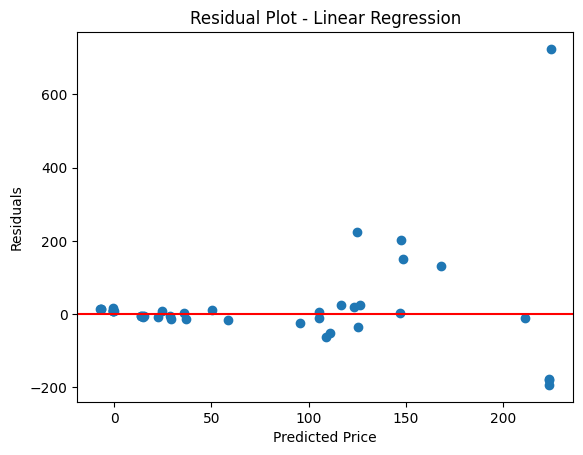

In [115]:
plt.scatter(y_pred_lin, residuals)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()

There is an increasing error at higher predicted values

On the right side (high predicted prices):

residuals become more spread out
some very large positive/negative errors

This is called:

> Heteroscedasticity

- (more error as price increases)

The residual plot shows non-random structure and increasing variance at higher predicted values. This indicates that the linear model is not fully capturing the underlying relationships in the data, suggesting the presence of non-linear effects and potential heteroscedasticity.

#### Polynomial Regression Pipeline

We must include scaling + polynomial expansion.

In [117]:
from sklearn.preprocessing import PolynomialFeatures

In [118]:
# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [119]:
# Train Polynomial Regression
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [120]:
# Make predictions
y_pred_poly = poly_model.predict(X_test_poly)

In [121]:
# Evaluate
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial MAE:", mae_poly)
print("Polynomial MSE:", mse_poly)
print("Polynomial RMSE:", rmse_poly)
print("Polynomial R2:", r2_poly)

Polynomial MAE: 63.92770520425058
Polynomial MSE: 19662.47201709882
Polynomial RMSE: 140.22293684379463
Polynomial R2: 0.27627650757096944


- MAE increased from KSh 59.97M to KSh 63.93M, meaning the average prediction error became larger.
- MSE increased from 18,760.84 to 19,662.47, indicating larger errors.
- RMSE increased from KSh 136.97M to KSh 140.22M, suggesting the polynomial model also made larger prediction errors.
- R² decreased from 0.309 to 0.276. The Polynomial model explains only 27.6% of the variation in property prices compared with 30.9% for Linear Regression.

Conclusion

Polynomial Regression did not improve the model's performance. Compared with Linear Regression, it produced higher MAE, MSE and RMSE and a lower R². This suggests that adding second-degree polynomial terms did not capture useful non-linear relationships in the current features and may have added unnecessary complexity.

#### Ridge Regression (Regularization)

In [123]:
from sklearn.linear_model import Ridge

In [124]:
# Create Ridge model
ridge_model = Ridge(alpha=1.0)

In [125]:
# Train the model
ridge_model.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [126]:
# Make predictions
y_pred_ridge = ridge_model.predict(X_test_scaled)

In [127]:
# Evaluate
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge MAE:", mae_ridge)
print("Ridge MSE:", mse_ridge)
print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Ridge MAE: 59.83520633212837
Ridge MSE: 18774.010230661905
Ridge RMSE: 137.0182842932355
Ridge R2: 0.30897843164291194


- MAE: Ridge improved very slightly from 59.97M → 59.84M.
- MSE: Ridge is slightly worse: 18,760.84 → 18,774.01.
- RMSE: Ridge is also slightly worse: 136.97M → 137.02M.
- R²: Essentially unchanged at 0.309.

So with alpha=1.0, Ridge has not meaningfully improved your model.

Conclusion

Ridge Regression produced performance very similar to Linear Regression. It achieved an MAE of KSh 59.84 million and an R² of 0.309, compared with KSh 59.97 million and 0.309 for Linear Regression. However, its MSE and RMSE were marginally higher. Therefore, applying Ridge regularization with an alpha of 1.0 did not provide a meaningful improvement in predictive performance.

## Tuning

In [128]:
from sklearn.model_selection import GridSearchCV

alpha_values = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

ridge = Ridge()

ridge_grid = GridSearchCV(
    ridge,
    alpha_values,
    cv=5,
    scoring='neg_mean_squared_error'
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best alpha:", ridge_grid.best_params_)

Best alpha: {'alpha': 10}


In [129]:
# Get the best Ridge model
best_ridge = ridge_grid.best_estimator_

# Make predictions on the test set
y_pred_ridge = best_ridge.predict(X_test_scaled)

In [130]:
# Evaluate
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Best Alpha:", ridge_grid.best_params_['alpha'])
print("Ridge MAE:", mae_ridge)
print("Ridge MSE:", mse_ridge)
print("Ridge RMSE:", rmse_ridge)
print("Ridge R2:", r2_ridge)

Best Alpha: 10
Ridge MAE: 59.0016552710264
Ridge MSE: 18912.555163039346
Ridge RMSE: 137.52292595432715
Ridge R2: 0.30387895980481594


In [131]:
# Model Performance Summary
performance = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Ridge Regression'
    ],
    'MAE (KSh M)': [
        mae,
        mae_poly,
        mae_ridge
    ],
    'MSE': [
        mse,
        mse_poly,
        mse_ridge
    ],
    'RMSE (KSh M)': [
        rmse,
        rmse_poly,
        rmse_ridge
    ],
    'R²': [
        r2,
        r2_poly,
        r2_ridge
    ]
})

performance

,Model,MAE (KSh M),MSE,RMSE (KSh M),R²
0,Linear Regression,59.967898,18760.843911,136.970230,0.309463
1,Polynomial Regression,63.927705,19662.472017,140.222937,0.276277
2,Ridge Regression,59.001655,18912.555163,137.522926,0.303879


## model explainability

### Examine the Linear Regression coefficients

In [132]:
# Get feature names
feature_names = X_train.columns

# Get model coefficients
coefficients = lin_model.coef_

# Create a DataFrame
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute coefficient
coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

coef_df

,Feature,Coefficient,Absolute_Coefficient
3,propertyType_Vacant Land,72.771690,72.771690
2,propertyType_Townhouse,32.316005,32.316005
1,bathroom,25.307987,25.307987
0,Bedroom,13.262080,13.262080
4,Location_encoded,-1.155971,1.155971


- Vacant Land has the strongest influence, with a coefficient of +72.77. Holding other variables constant, being classified as vacant land is associated with a substantial increase in predicted price relative to the reference property type.
- Townhouse is the second strongest feature, with a coefficient of +32.32.
- Bathroom has a coefficient of +25.31, indicating that properties with more bathrooms tend to have higher predicted prices, all else being equal.
- Bedroom has a smaller positive coefficient of +13.26, suggesting bedrooms have a positive but comparatively weaker influence on predicted price.
- Location_encoded has a coefficient of only −1.16, making it the weakest feature in this model. However, because location was encoded numerically, we should not rely heavily on this interpretation.

In [146]:
df["error"] = df["actual_price"] - df["predicted_price"]

df.groupby("location")["error"].mean()

KeyError: 'actual_price'

### 1. SHAP Explainability

SHAP tells us how much each feature contributes to each prediction and whether that contribution pushes the predicted price up or down.

Install SHAP if needed

```python
!pip install shap
```

### Create the SHAP explainer

In [133]:
import shap

explainer = shap.Explainer(
    lin_model,
    X_train_scaled,
    feature_names=X_train.columns
)

shap_values = explainer(X_test_scaled)

c:\Users\user\Desktop\data-science-class\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 161 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=161 when initializing the masker.


### 2. SHAP Summary Plot

This is the most useful SHAP visualization for your project.

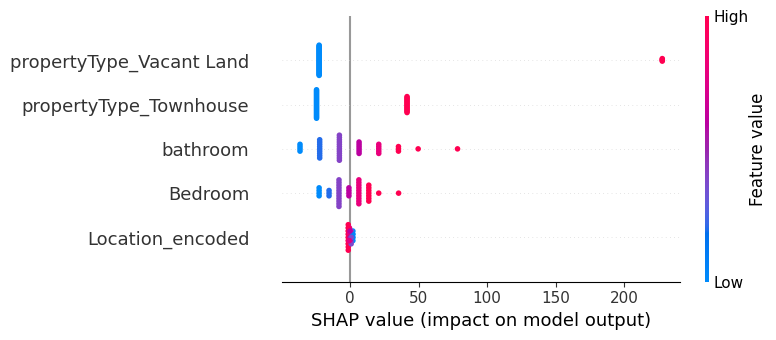

In [134]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_train.columns
)

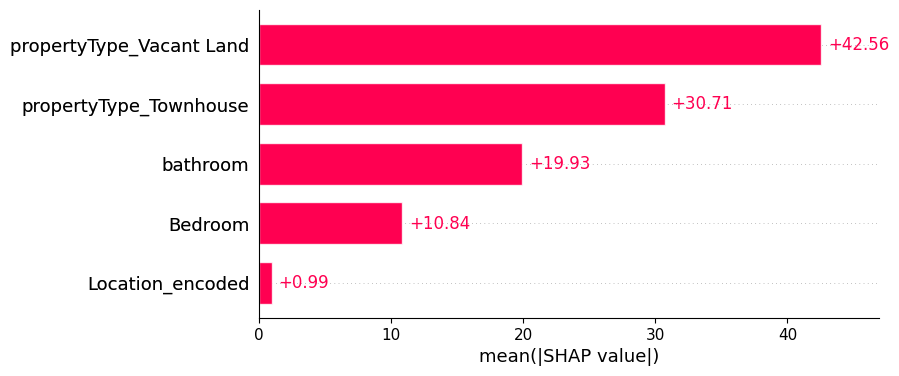

In [135]:
shap.plots.bar(shap_values)

### 4. SHAP Individual Prediction

We can also explain one particular property's predicted price.

In [140]:
X_test.iloc[0]

Bedroom                     4.00000
bathroom                    4.00000
propertyType_Townhouse      1.00000
propertyType_Vacant Land    0.00000
Location_encoded            0.09901
Name: 95, dtype: float64

In [143]:
X_test_scaled[0]

array([ 0.4311903 ,  0.75458842,  1.23110723, -0.32053038, -0.16805024])

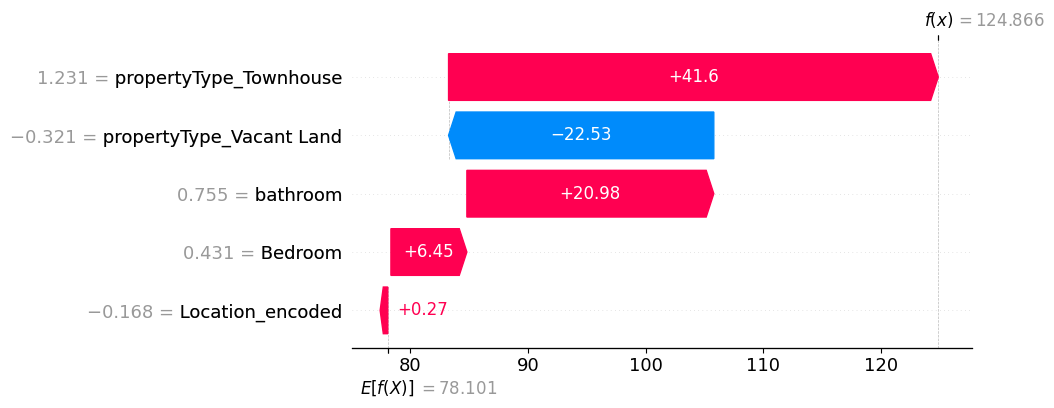

In [136]:
shap.plots.waterfall(shap_values[0])

### 5. LIME Explainability

LIME is slightly different.

Instead of explaining the entire model, LIME explains one specific prediction by creating small variations around that observation and seeing how the model responds.

In [137]:
from lime.lime_tabular import LimeTabularExplainer

In [138]:
lime_explainer = LimeTabularExplainer(
    X_train_scaled,
    feature_names=X_train.columns,
    mode='regression',
    random_state=42
)

### 6. Explain One Property Using LIME

Let's explain the first property in the test set:

In [139]:
lime_exp = lime_explainer.explain_instance(
    X_test_scaled[0],
    lin_model.predict,
    num_features=len(X_train.columns)
)

In [145]:
lime_exp.as_list()

[('propertyType_Vacant Land <= -0.32', -224.64317108955754),
 ('-0.81 < propertyType_Townhouse <= 1.23', 38.0090752946844),
 ('-0.38 < bathroom <= 0.75', 17.628121548816683),
 ('-0.12 < Bedroom <= 0.43', 6.696776018307107),
 ('-1.09 < Location_encoded <= -0.00', -0.004423553832488667)]

| Feature                    | LIME contribution | Interpretation                     |
| -------------------------- | ----------------: | ---------------------------------- |
| `propertyType_Vacant Land` |       **-224.64** | Strongly decreases predicted price |
| `propertyType_Townhouse`   |        **+38.01** | Increases predicted price          |
| `bathroom`                 |        **+17.63** | Increases predicted price          |
| `Bedroom`                  |         **+6.70** | Slightly increases predicted price |
| `Location_encoded`         |        **-0.004** | Essentially no effect              |


#### Lasso Regression (Feature Selection)

In [338]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))

Lasso RMSE: 51.6777307378921
Lasso R2: 0.639289939175312


#### Final Comparison Table

In [339]:
results = pd.DataFrame({
    "Model": ["Linear", "Polynomial", "Ridge", "Lasso"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lin)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ],
    "R2": [
        r2_score(y_test, y_pred_lin),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

results

,Model,RMSE,R2
0,Linear,51.678899,0.639274
1,Polynomial,60.398824,0.507271
2,Ridge,51.572562,0.640757
3,Lasso,51.677731,0.639290
